# Active-Subspace Quadrature vs Sampling — Depth-32 ReLU MLP

Companion to `covariance_spectrum_depth32.ipynb`. That notebook showed the propagated
covariance concentrating in a few directions with depth. This one asks whether we can
*spend* that structure: use the top input directions of the network's (soft-gate)
Jacobian to place a small deterministic quadrature grid, and handle everything
orthogonal to it analytically or with cheap sampling.

**Idea under test.** For the mean `E[f(x)]` over `x ~ N(0, I)`, split the input as
`x = U y + z` with `U` the top-`r` right-singular directions of the Jacobian and
`z ~ N(0, I - UU^T)` the orthogonal complement. Then

```
E[f] = E_y [ E[f | y] ]
```

where the outer integral is `r`-dimensional (Gauss–Hermite quadrature) and the inner
conditional expectation is either propagated analytically (mean/covariance
propagation with input mean `U y` and covariance `I - UU^T`) or estimated with a few
conditional samples. Variance-reduction baselines that exploit the same low-rank
structure for free — antithetic pairs and an affine control variate — are included,
since any quadrature scheme has to beat those first.

**Methods compared, all at analytically counted FLOPs** (a real submission would
route these through flopscope):

| method | type | what it exploits |
|---|---|---|
| plain MC | unbiased sampling | nothing |
| antithetic MC | unbiased sampling | odd symmetry (kills odd Hermite components) |
| affine control variate | unbiased sampling | soft-gate linearization, exact affine mean |
| mean prop (diag) | deterministic | rectified-Gaussian marginals |
| full-cov prop | deterministic | full covariance (as in the companion notebook) |
| GH-prop (diag / full-cov) | deterministic | active subspace + conditional propagation |
| GH × conditional MC | sampling on a grid | active subspace stratification |

Score is final-layer MSE against a large antithetic Monte Carlo ground truth,
matching the challenge's final-layer scoring.


In [1]:
from __future__ import annotations

import math
import time

import numpy as np
import matplotlib.pyplot as plt

WIDTH = 128
DEPTH = 32
SEED = 0

N, D = WIDTH, DEPTH


def build_weights(width: int, depth: int, seed: int = 0) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    scale = math.sqrt(2.0 / width)
    return [rng.standard_normal((width, width)) * scale for _ in range(depth)]


weights = build_weights(WIDTH, DEPTH, SEED)
W_SQ = [w * w for w in weights]

FWD_FLOPS = D * (2 * N * N + N)          # one forward pass, per sample
PROP_FLOPS = D * (4 * N * N + 12 * N)    # one diagonal mean/var propagation
FULLCOV_PROP_FLOPS = D * (4 * N**3 + 3 * N * N + 12 * N)


def forward_final(X: np.ndarray) -> np.ndarray:
    Z = X
    for w in weights:
        Z = np.maximum(Z @ w, 0.0)
    return Z


_erf = np.vectorize(math.erf, otypes=[np.float64])


def norm_pdf(x):
    return np.exp(-0.5 * x * x) / math.sqrt(2.0 * math.pi)


def norm_cdf(x):
    return 0.5 * (1.0 + _erf(x / math.sqrt(2.0)))


print(f"width={WIDTH} depth={DEPTH} seed={SEED};  forward pass = {FWD_FLOPS:.3g} FLOPs/sample")

width=128 depth=32 seed=0;  forward pass = 1.05e+06 FLOPs/sample


## Ground truth

Antithetic Monte Carlo with 200k pairs (400k forward passes). The noise floor below
is the expected MSE of the ground-truth estimate itself — method MSEs are only
meaningful well above it.


In [2]:
def ground_truth(total_pairs=200_000, batch_pairs=25_000, seed=1234):
    rng = np.random.default_rng(seed)
    sum_p = np.zeros(N)
    sum_p2 = np.zeros(N)
    done = 0
    while done < total_pairs:
        b = min(batch_pairs, total_pairs - done)
        X = rng.standard_normal((b, N))
        P = 0.5 * (forward_final(X) + forward_final(-X))
        sum_p += P.sum(axis=0)
        sum_p2 += (P * P).sum(axis=0)
        done += b
    gt = sum_p / done
    pair_var = np.maximum(sum_p2 / done - gt * gt, 0.0)
    noise_floor = pair_var.mean() / done
    return gt, noise_floor


t0 = time.time()
gt, NOISE_FLOOR = ground_truth()
print(f"ground truth in {time.time() - t0:.1f}s")
print(f"mean |E[x_d]| = {np.abs(gt).mean():.4g}")
print(f"noise floor MSE = {NOISE_FLOOR:.3g}")


def mse(est: np.ndarray) -> float:
    return float(np.mean((est - gt) ** 2))

ground truth in 8.4s
mean |E[x_d]| = 0.6195
noise floor MSE = 3.66e-07


## Propagation machinery

Three pieces:

- `meanvar_prop` — mean + diagonal-variance propagation via exact rectified-Gaussian
  marginals (independence assumption), batched over quadrature nodes.
- an **affine surrogate** `h(x)`: each ReLU replaced by its best affine fit under the
  propagated Gaussian marginal (`gain = Phi(alpha)`). `h` is affine in `x`, so
  `E[h] = h(0)` exactly, which equals the mean-propagation output — this makes
  `h` a control variate with *analytically known mean*.
- `fullcov_prop` — full covariance propagation with the linearized ReLU covariance
  rule, identical to the update in `covariance_spectrum_depth32.ipynb`.


In [3]:
def meanvar_prop(m0: np.ndarray, v0: np.ndarray, store_layers: bool = False):
    """Mean + diagonal-variance propagation. m0/v0 are (N,) or (N, M)."""
    m, v = m0, v0
    layers = []
    for w, w2 in zip(weights, W_SQ):
        mu = w.T @ m
        var = np.maximum(w2.T @ v, 1e-300)
        sig = np.sqrt(var)
        a = mu / sig
        Phi, phi = norm_cdf(a), norm_pdf(a)
        m = mu * Phi + sig * phi
        ez2 = (mu * mu + var) * Phi + mu * sig * phi
        v = np.maximum(ez2 - m * m, 0.0)
        if store_layers:
            layers.append((mu, sig, Phi, m.copy()))
    return m, v, layers


MP_FINAL, MP_VAR, AFFINE_LAYERS = meanvar_prop(np.zeros(N), np.ones(N), store_layers=True)


def surrogate_h(X: np.ndarray) -> np.ndarray:
    """Affine surrogate; E[h(x)] over x ~ N(0, I) equals MP_FINAL exactly."""
    Z = X
    for (mu_pre, _sig, gain, m_post), w in zip(AFFINE_LAYERS, weights):
        Z = m_post + gain * (Z @ w - mu_pre)
    return Z


def fullcov_prop(m0: np.ndarray, cov0: np.ndarray) -> np.ndarray:
    """Mean via full-covariance propagation (linearized ReLU covariance rule)."""
    m, cov = m0, cov0
    for w in weights:
        mu = w.T @ m
        cov_pre = w.T @ cov @ w
        cov_pre = 0.5 * (cov_pre + cov_pre.T)
        var = np.maximum(np.diag(cov_pre), 1e-300)
        sig = np.sqrt(var)
        a = mu / sig
        Phi, phi = norm_cdf(a), norm_pdf(a)
        m = mu * Phi + sig * phi
        ez2 = (mu * mu + var) * Phi + mu * sig * phi
        v_post = np.maximum(ez2 - m * m, 0.0)
        cov = np.outer(Phi, Phi) * cov_pre
        np.fill_diagonal(cov, v_post)
    return m


print("mean prop (diag) final-layer MSE:", f"{mse(MP_FINAL):.4g}")

mean prop (diag) final-layer MSE: 0.001859


## Active subspace of the soft-gate Jacobian

The linear part of the surrogate, `J = G_d W_d^T ... G_1 W_1^T`, is a product of 32
gated random matrices. The Lyapunov analysis of such products predicts exponentially
separating singular values — i.e. the input-output map should be dominated by very
few input directions. We recover the top directions with subspace iteration using
only JVP/VJP chains (cheap, budget-friendly), and separately compute the exact
spectrum as a diagnostic (not counted toward any estimator's budget).


cumulative sv^2 share, top 6 directions: [0.9774 0.9893 0.9933 0.9967 0.9982 0.999 ]


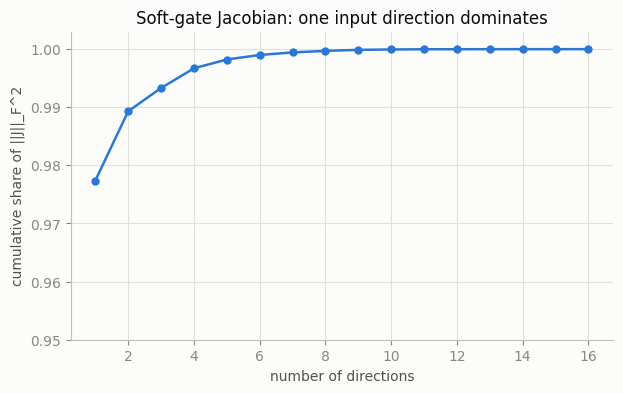

In [4]:
def soft_jvp(V: np.ndarray) -> np.ndarray:
    Z = V
    for (_mu, _sig, gain, _m), w in zip(AFFINE_LAYERS, weights):
        Z = gain[:, None] * (w.T @ Z)
    return Z


def soft_vjp(V: np.ndarray) -> np.ndarray:
    Z = V
    for (_mu, _sig, gain, _m), w in zip(reversed(AFFINE_LAYERS), reversed(weights)):
        Z = w @ (gain[:, None] * Z)
    return Z


def active_subspace(r: int, iters: int = 4, oversample: int = 2, seed: int = 7):
    """Top-r right-singular directions of J via subspace iteration."""
    rng = np.random.default_rng(seed)
    q = r + oversample
    V, _ = np.linalg.qr(rng.standard_normal((N, q)))
    for _ in range(iters):
        V, _ = np.linalg.qr(soft_vjp(soft_jvp(V)))
    s = np.linalg.norm(soft_jvp(V), axis=0)
    order = np.argsort(-s)
    V, s = V[:, order], s[order]
    flops = (iters * 2 + 1) * q * 2 * N * N * D
    return V[:, :r], s, flops


# Diagnostic: exact spectrum of J (full Jacobian; NOT part of any estimator budget)
sv = np.linalg.svd(soft_jvp(np.eye(N)), compute_uv=False)
cum_share = np.cumsum(sv**2) / np.sum(sv**2)
print("cumulative sv^2 share, top 6 directions:", np.round(cum_share[:6], 4))

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE = "#2a78d6"

fig, ax = plt.subplots(figsize=(7, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(np.arange(1, 17), cum_share[:16], color=BLUE, linewidth=1.8,
        marker="o", markersize=5)
ax.set_xlabel("number of directions", color=INK2)
ax.set_ylabel("cumulative share of ||J||_F^2", color=INK2)
ax.set_title("Soft-gate Jacobian: one input direction dominates", color=INK, fontsize=12)
ax.set_ylim(0.95, 1.003)
ax.grid(True, color=GRID, linewidth=0.8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=MUTED)
plt.show()

## Estimators

All estimator costs are counted analytically (matmul-dominated terms). The
Gauss–Hermite × conditional-MC variant allocates antithetic pairs to nodes
**proportionally to node weight** — equal allocation across GH-weighted strata is
provably *worse* than iid sampling (the center node carries most of the probability
mass), which is an easy trap.


In [5]:
def gh_nodes(m: int, r: int):
    """Tensor Gauss-Hermite grid for N(0, I_r): nodes (m^r, r), weights (m^r,)."""
    x, wt = np.polynomial.hermite_e.hermegauss(m)
    wt = wt / wt.sum()
    grids = np.meshgrid(*([x] * r), indexing="ij")
    Y = np.stack([g.ravel() for g in grids], axis=1)
    wgrids = np.meshgrid(*([wt] * r), indexing="ij")
    Wt = np.ones(m**r)
    for g in wgrids:
        Wt = Wt * g.ravel()
    return Y, Wt


def est_mc(k: int, rng):
    X = rng.standard_normal((k, N))
    return forward_final(X).mean(axis=0), k * FWD_FLOPS


def est_antithetic(k: int, rng):
    h = k // 2
    X = rng.standard_normal((h, N))
    est = 0.5 * (forward_final(X).mean(axis=0) + forward_final(-X).mean(axis=0))
    return est, k * FWD_FLOPS


def est_cv(k: int, rng):
    """Affine control variate: E[f] = E[h] + E[f - h], E[h] known exactly.
    Unbiased; costs ~2 forward passes per sample."""
    X = rng.standard_normal((k, N))
    resid = forward_final(X) - surrogate_h(X)
    return MP_FINAL + resid.mean(axis=0), 2 * k * FWD_FLOPS + PROP_FLOPS


def est_gh_prop_diag(r: int, m: int):
    U, _s, sub_flops = active_subspace(r)
    Y, Wt = gh_nodes(m, r)
    M = Y.shape[0]
    M0 = U @ Y.T
    v0 = np.maximum(1.0 - (U * U).sum(axis=1), 1e-12)
    V0 = np.repeat(v0[:, None], M, axis=1)
    m_fin, _, _ = meanvar_prop(M0, V0)
    return m_fin @ Wt, M * PROP_FLOPS + sub_flops


def est_gh_prop_fullcov(r: int, m: int):
    U, _s, sub_flops = active_subspace(r)
    Y, Wt = gh_nodes(m, r)
    cov0 = np.eye(N) - U @ U.T
    est = np.zeros(N)
    for j in range(Y.shape[0]):
        est = est + Wt[j] * fullcov_prop(U @ Y[j], cov0)
    return est, Y.shape[0] * FULLCOV_PROP_FLOPS + sub_flops


def est_gh_mc(r: int, m: int, k_total: int, rng):
    """Conditional MC on the GH grid: antithetic pairs in the orthogonal
    complement, pairs allocated proportionally to node weight."""
    U, _s, sub_flops = active_subspace(r)
    Y, Wt = gh_nodes(m, r)
    M = Y.shape[0]
    total_pairs = max(k_total // 2, M)
    pairs = np.maximum(np.round(Wt * total_pairs).astype(int), 1)
    node_means = np.zeros((M, N))
    for j in range(M):
        Xi = rng.standard_normal((pairs[j], N))
        Z = Xi - (Xi @ U) @ U.T            # z ~ N(0, I - UU^T)
        base = (U @ Y[j])[None, :]
        node_means[j] = 0.5 * (forward_final(base + Z).mean(axis=0)
                               + forward_final(base - Z).mean(axis=0))
    n_fwd = 2 * int(pairs.sum())
    flops = n_fwd * FWD_FLOPS + sub_flops + n_fwd * 2 * N * r
    return Wt @ node_means, flops

## The comparison

Stochastic estimators are averaged over 16 repeat runs (the MSE of a single run is
itself a noisy chi-square-like quantity). Deterministic estimators are single
evaluations — their error is pure bias.


In [6]:
t0 = time.time()
R = 16
K_LIST = [64, 256, 1024, 4096, 16384]
results: dict[str, dict[str, list[float]]] = {}


def record(name: str, flops: float, mse_val: float):
    entry = results.setdefault(name, {"flops": [], "mse": []})
    entry["flops"].append(flops)
    entry["mse"].append(mse_val)


for mi, (name, fn) in enumerate([("plain MC", est_mc),
                                 ("antithetic MC", est_antithetic),
                                 ("affine control variate", est_cv)]):
    for k in K_LIST:
        ms, fl = [], None
        for rep in range(R):
            rng = np.random.default_rng(10_000 + 1009 * mi + 97 * rep + k)
            est, fl = fn(k, rng)
            ms.append(mse(est))
        record(name, fl, float(np.mean(ms)))

for k in [256, 1024, 4096]:
    ms, fl = [], None
    for rep in range(R):
        rng = np.random.default_rng(50_000 + 31 * rep + k)
        est, fl = est_gh_mc(1, 9, k, rng)
        ms.append(mse(est))
    record("GH x conditional MC (r=1)", fl, float(np.mean(ms)))

record("mean prop (diag)", PROP_FLOPS, mse(MP_FINAL))

est_fc = fullcov_prop(np.zeros(N), np.eye(N))
record("full-cov prop", FULLCOV_PROP_FLOPS, mse(est_fc))

for r, m in [(1, 5), (1, 9), (1, 17), (2, 7)]:
    est, fl = est_gh_prop_diag(r, m)
    name = "GH-prop diag" if r == 1 else "GH-prop diag (r=2)"
    record(name, fl, mse(est))

for r, m in [(1, 5), (1, 9)]:
    est, fl = est_gh_prop_fullcov(r, m)
    record("GH-prop full-cov", fl, mse(est))

print(f"sweep finished in {time.time() - t0:.1f}s\n")
print(f"{'method':<28}{'FLOPs':>12}{'final-layer MSE':>18}")
for name, entry in results.items():
    for fl, ms_ in zip(entry["flops"], entry["mse"]):
        print(f"{name:<28}{fl:>12.3g}{ms_:>18.4g}")

sweep finished in 41.9s

method                             FLOPs   final-layer MSE
plain MC                        6.74e+07          0.003295
plain MC                        2.69e+08         0.0006205
plain MC                        1.08e+09         0.0001606
plain MC                        4.31e+09         3.415e-05
plain MC                        1.72e+10         1.378e-05
antithetic MC                   6.74e+07          0.001972
antithetic MC                   2.69e+08          0.000619
antithetic MC                   1.08e+09         7.162e-05
antithetic MC                   4.31e+09         3.985e-05
antithetic MC                   1.72e+10          1.73e-05
affine control variate          1.37e+08          0.002207
affine control variate          5.41e+08         0.0004736
affine control variate          2.16e+09         5.761e-05
affine control variate          8.63e+09         3.587e-05
affine control variate          3.45e+10         7.185e-06
GH x conditional MC (r=1)      

## Accuracy vs compute

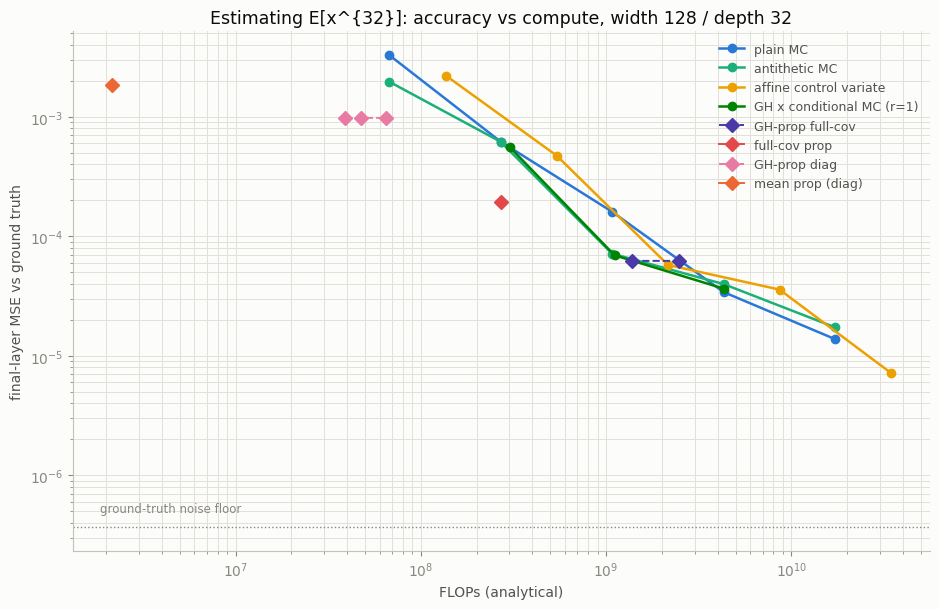

In [7]:
PALETTE = {
    "plain MC":                "#2a78d6",  # blue
    "antithetic MC":           "#1baf7a",  # aqua
    "affine control variate":  "#eda100",  # yellow
    "GH x conditional MC (r=1)": "#008300",  # green
    "GH-prop full-cov":        "#4a3aa7",  # violet
    "full-cov prop":           "#e34948",  # red
    "GH-prop diag":            "#e87ba4",  # magenta
    "mean prop (diag)":        "#eb6834",  # orange
}
DETERMINISTIC = {"mean prop (diag)", "full-cov prop", "GH-prop diag", "GH-prop full-cov"}

fig, ax = plt.subplots(figsize=(9.5, 6.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for name, color in PALETTE.items():
    entry = results.get(name)
    if entry is None:
        continue
    fl = np.array(entry["flops"], dtype=float)
    ms_ = np.array(entry["mse"], dtype=float)
    order = np.argsort(fl)
    fl, ms_ = fl[order], ms_[order]
    if name in DETERMINISTIC:
        ax.loglog(fl, ms_, color=color, linewidth=1.4, linestyle="--" if len(fl) > 1 else "-",
                  marker="D", markersize=7, label=name)
    else:
        ax.loglog(fl, ms_, color=color, linewidth=1.8, marker="o", markersize=6,
                  label=name)

ax.axhline(NOISE_FLOOR, color=MUTED, linewidth=1.0, linestyle=":")
ax.text(ax.get_xlim()[0] * 1.4, NOISE_FLOOR * 1.35, "ground-truth noise floor",
        color=MUTED, fontsize=8.5)

ax.set_xlabel("FLOPs (analytical)", color=INK2)
ax.set_ylabel("final-layer MSE vs ground truth", color=INK2)
ax.set_title("Estimating E[x^{32}]: accuracy vs compute, width 128 / depth 32",
             color=INK, fontsize=12.5)
ax.grid(True, which="both", color=GRID, linewidth=0.7)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.tick_params(which="both", colors=MUTED)
leg = ax.legend(loc="upper right", fontsize=9, frameon=False)
for t in leg.get_texts():
    t.set_color(INK2)
fig.tight_layout()
plt.show()

## Reading the results (seed 0)

- **The Jacobian spectrum is extremely spiked**: the single top input direction
  carries ~98% of `||J||_F^2` at depth 32 — the Lyapunov separation predicted by
  random-matrix-product theory. Consequences: `r = 1` is the right active-subspace
  size here, and adding quadrature dimensions (`r = 2`) only dilutes node resolution.
- **Quadrature converges instantly**: GH-prop results are identical for m = 5, 9, 17
  nodes. The remaining error is *not* quadrature error — it is the bias of the
  conditional propagation. With diagonal propagation that bias floor is ~1e-3
  (about 2x better than plain mean propagation); with full-covariance propagation
  it drops to ~6e-5, i.e. **conditioning on one direction cuts full-cov prop's bias
  by ~3x** for a handful of extra propagation passes.
- **Deterministic beats sampling at low budget**: pointwise, every propagation
  method sits below the sampling curves at its own budget — e.g. full-cov prop
  reaches 1.9e-4 at 2.7e8 FLOPs, ~3x better than any sampler at that cost.
  GH-prop (full-cov) reaches 6.2e-5 at ~1.4e9 FLOPs with zero variance; plain MC
  needs roughly 2x more compute for the same MSE, and antithetic MC is at rough
  parity. Its real advantage is qualitative: the error is pure bias with a known
  refinement path (better conditional propagation), rather than variance.
- **At large budgets, unbiased sampling wins again**: the affine control variate is
  the best method at 1e10+ FLOPs, because deterministic methods hit their bias
  floor while unbiased estimators keep improving. Antithetic pairs and the control
  variate largely remove the same (odd / linear) variance component — stacking them
  is redundant (antithetic averaging of an affine surrogate is exactly constant).
- **GH x conditional MC** is only at parity with antithetic MC: stratifying the top
  input direction mostly removes linear variance, which antithetic pairs already
  remove for free.

**Practical takeaway for the challenge.** The winning shape for a mid-budget
estimator looks like: *(top-1 active subspace) x (Gauss-Hermite nodes) x (conditional
covariance propagation)*, optionally debiased with a small unbiased MC correction
(the control-variate trick, using the conditional propagation output as the known
mean). The full-covariance step is the FLOP bottleneck (`4n^3` per layer per node) —
replacing it with a **diagonal-plus-low-rank propagator** (as suggested by the
covariance spectrum in the companion notebook: the ReLU gain update is a diagonal
congruence, which preserves rank exactly) would cut that to `O(n^2 r)` and make the
whole scheme cheap enough to dominate a much wider budget range.

**Caveats.**

- Single seed, single width/depth; the crossover points will move with `n`, `d`, and
  the budget. The spectral concentration itself should only strengthen with depth.
- The conditional full-cov bias floor (~6e-5) is inherited from the linearized
  off-diagonal ReLU rule `Phi(alpha_i) Phi(alpha_j) cov_ij`, which is least accurate
  for strongly correlated pairs — exactly the regime the top directions live in. An
  exact bivariate `E[ReLU ReLU]` (Hermite series) on the top-r block is the natural
  refinement.
- FLOPs here are hand-counted and matmul-dominated; flopscope's accounting (and the
  residual wall-time term) will shift constants, not conclusions.
